In [1]:
# %pip install pandas

In [ ]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/Womens Clothing E-Commerce Reviews.csv')

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='str')

In [4]:
import re

In [5]:
#리뷰 텍스트
text_col = 'Review Text'

#결측치 제거 (리뷰가 존재 하지 않는 데이터들)
df = df.dropna(subset=[text_col])

In [6]:
# 텍스트 정리 함수
def clean_text(text):
    # 소문자 변환
    text = text.lower()
    # 영어와 공백만 남김, 그 외의 특수문자는 분석에 방해될 수 있음.
    text = re.sub(r'[^a-zA-Z\s]','', text)
    # 공백이 여러 개인 것을 하나로 정리.
    text = re.sub(r'\s+',' ', text).strip()
    return text

In [7]:
# 적용 단계
df['cleaned_text'] = df[text_col].apply(clean_text)

In [8]:
# 짧은 리뷰 제거, 의미 없는 데이터 제거해서 품질 개선.
df = df[df['cleaned_text'].str.len() > 5]

df.head(10)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,cleaned_text
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,absolutely wonderful silky and sexy and comfor...
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,love this dress its sooo pretty i happened to ...
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,i had such high hopes for this dress and reall...
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,i love love love this jumpsuit its fun flirty ...
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,this shirt is very flattering to all due to th...
5,5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,i love tracy reese dresses but this one is not...
6,6,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,i aded this in my basket at hte last mintue to...
7,7,858,39,"Shimmer, surprisingly goes with lots","I ordered this in carbon for store pick up, an...",4,1,4,General Petite,Tops,Knits,i ordered this in carbon for store pick up and...
8,8,1077,24,Flattering,I love this dress. i usually get an xs but it ...,5,1,0,General,Dresses,Dresses,i love this dress i usually get an xs but it r...
9,9,1077,34,Such a fun dress!,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5,1,0,General,Dresses,Dresses,im and lbs i ordered the s petite to make sure...


In [10]:
# 1. 이탈 기준
# 이탈 위험 사용자는 다음 조건 중 하나 이상을 만족하는 사용자로 정의.
# Rating<=2 or Recommend = 0
# 이때, 평점이 높은데 추천을 안하거나 / 평점은 낮은데 추천을 하는 사용자가 존재할 수 있음.
# ===============================================================================
# 2. 연령 그룹
# 10~20대/30~40대/50~60대/70대 이상
# ===============================================================================
# 3. 키워드 분석
# 긍정/부정 단어 기반으로 CRM 분석 => 이탈 위험 사용자 그룹에서 자주 등장하는 키워드 분석.

In [9]:
# 사용자 분류 함수
def classify_user(row):
    # 정상 사용자
    if row['Rating'] >= 4 and row['Recommended IND'] == 1:
        return 'Stable' 
    # 이탈 사용자
    elif row['Rating'] <= 2 and row['Recommended IND'] == 0:
        return 'Churn' 
    #잠재 이탈
    elif row['Rating'] >= 4 and row['Recommended IND'] == 0:
        return 'Hidden Churn'
    #모순 사용자
    elif row['Rating'] <= 2 and row['Recommended IND'] == 1:
        return 'Inconsistent'
    else:
        return 'Neutral'

In [10]:
# 사용자 분류 확인
df['user_type'] = df.apply(classify_user, axis=1)

df['user_type'].value_counts()

user_type
Stable          17261
Neutral          2823
Churn            2261
Hidden Churn      187
Inconsistent      109
Name: count, dtype: int64

In [11]:
# 이탈 사용자와 잠재적 이탈 가능성이 있는 사용자 따로 보기
churn_df = df[df['user_type'] == 'Churn']
hidden_churn_df = df[df['user_type'] == 'Hidden Churn']

In [12]:
from collections import Counter

In [28]:
# 텍스트를 합친 후 단어들을 나누어서 가장 많이 나오는 순서대로 정렬. 

# 기본 불용어 리스트
negative_words = [
    'bad','poor','small','tight','return','disappointed',
    'cheap','problem','issue','wrong','uncomfortable',
    'fit','size','too','not'
]

def get_negative_words(df, top_n = 20):
    words = " ".join(df['cleaned_text']).split()
    filtered = [w for w in words if w in negative_words]
    return Counter(filtered).most_common(top_n)
   



In [29]:
# 이탈 사용자 키워드
churn_keywords = get_negative_words(churn_df)
# 잠재적 이탈 키워드
hidden_keywords = get_negative_words(hidden_churn_df)

print("Churn Keywards:", churn_keywords)
print("\nHidden Keywards:", hidden_keywords)

Churn Keywards: [('not', 1365), ('too', 705), ('fit', 647), ('size', 616), ('small', 477), ('disappointed', 242), ('return', 189), ('cheap', 167), ('tight', 165), ('bad', 111), ('problem', 71), ('poor', 66), ('wrong', 57), ('issue', 33), ('uncomfortable', 22)]

Hidden Keywards: [('not', 106), ('fit', 80), ('size', 78), ('too', 72), ('small', 39), ('return', 24), ('tight', 14), ('disappointed', 11), ('problem', 6), ('bad', 4), ('wrong', 4), ('issue', 2), ('uncomfortable', 2)]


In [ ]:
# 해석
# churn(이탈 사용자) => 전반적으로 상품에 대한 만족도가 낮으며, 특히 사이즈 및 핏 문제와 함께 품질에 대한 불만이 주요 이탈 요인
# 품질+사이즈+전반적 불만

# hidden(잠재적 이탈) => 전반적인 만족도는 높지만, 사이즈 및 착용감과 관련된 반복적인 불편 요소가 존재하여 추천으로 이어지지 않은 사용자군으로 판단.
# 대부분 만족 but 사이즈 문제나 착용감 문제

# 이탈 사용자는 전반적인 품질 불만이 주요 원인, 잠재 이탈 사용자는 특정 요소들이 불편의 주요 요인으로 나타남.


In [ ]:
# 실제로 어떤 불만이 나타나는가?
def get_reviews(df, keyword, n = 3):
    return (
        df.loc[df['cleaned_text'].str.contains(keyword, na = False), 'Review Text']
        .dropna()
        .drop_duplicates()
        .head(n)
    )

In [31]:
keywords = ['size', 'fit', 'small']

for k in keywords:
    print(f"\n[{k}] 관련 리뷰")
    for r in get_reviews(churn_df, k):
        print("-", r)


[size] 관련 리뷰
- I have been waiting for this sweater coat to ship for weeks and i was so excited for it to arrive. this coat is not true to size and made me look short and squat. the sleeves are very wide (although long). as a light weight fall coat the sleeves don't need to be as wide because you wouldn't be layerng too much underneath. the buttons need to be moved at least three inches in for a nicer fit. i thought about redoing the buttons myself but the sleeves looked even more out of proportion with a tigh
- First, the fabric is beautiful and lovely for spring and summer. i really wanted to like this top, but the fitting is so awkward for me. i typically where a 0/xs, and sized up in the shirt to a size 2. it was very tight and pulled funny across the chest (size 32/a). i also found the cut at the shoulders very narrow (need a strapless bra) and made it look unflattering overall. had to return this one back to the store.
- The shirt is absolutely cute looking. but that's just that

In [18]:
# %pip install matplotlib

In [19]:
import matplotlib.pyplot as plt

In [20]:
def plot_keywards(keyword_data, title):
    words = [x[0] for x in keyword_data]
    counts = [x[1] for x in keyword_data]

    plt.figure(figsize=(10,5))
    plt.bar(words, counts)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

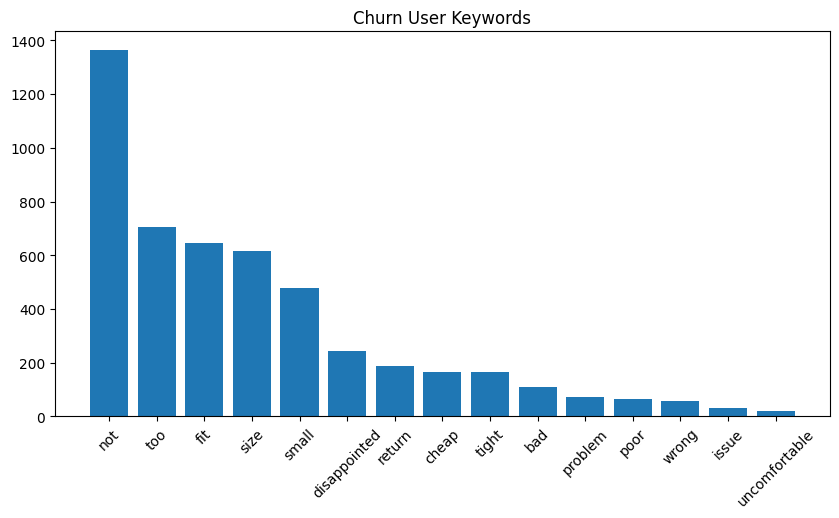

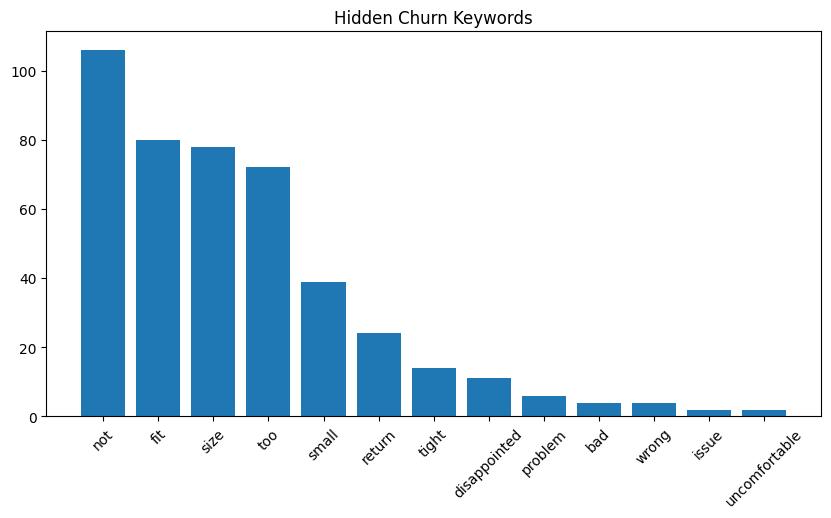

In [21]:
plot_keywards(churn_keywords, "Churn User Keywords")
plot_keywards(hidden_keywords, "Hidden Churn Keywords")

In [ ]:
# Churn 대상
# 품질에 대한 불만과 실망 경험이 주요 요인 / 리뷰 기반 신뢰도 강화 및 품질 개선 전략
# ============================================================================

# Hidden Churn 대상
# 사이즈와 핏 관련 불편이 지속적으로 나타남 / 개인화된 사이즈 추천 및 가이드 제공을 통해 사용자 만족도 개선

In [22]:
import pandas as pd

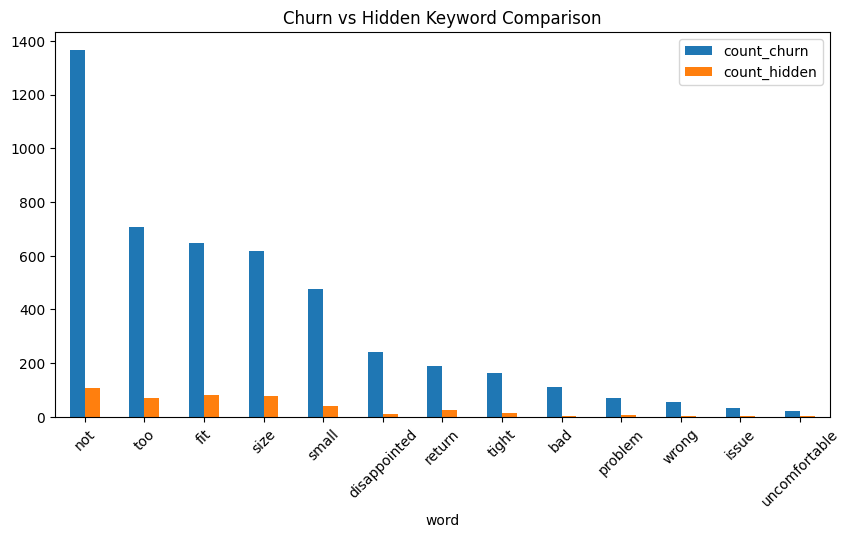

In [23]:
# 각 분석 결과를 데이터 프레임으로 변환
churn_df_plot = pd.DataFrame(churn_keywords, columns=['word', 'count'])
hidden_df_plot = pd.DataFrame(hidden_keywords, columns=['word', 'count'])

# 상위 공통 키워드 기준 Merge
merged = pd.merge(churn_df_plot, hidden_df_plot, on='word', how='inner', suffixes=('_churn', '_hidden'))

merged.set_index('word').plot(kind='bar', figsize=(10,5))
plt.title("Churn vs Hidden Keyword Comparison")
plt.xticks(rotation = 45)
plt.show()

In [ ]:
# 이탈 사용자와 잠재적 이탈 사용자 모두 size, fit, small 등의 키워드가 공통적으로 높은 빈도
# 사이즈 관련 문제가 주요 요인.